# Sub-Category: PGA-UNet vs Attention U-Net

> **Terminology note:** the **TOP-DICE** / **BOTTOM-DICE** groups are defined **post hoc** from the Attention U-Net Dice scores on the full test set; they are **not** pre-labeled easy/hard cases. These are simply the images on which the Attention U-Net baseline performs best or worst, after which the same images are re-evaluated with PGA-UNet for a fair comparison on the same baseline-derived subset.

| Section | Content |
|---|---|
| **0+1** | Run Attention U-Net on the **entire** test set -> sort by Dice -> define **easy_stems -> TOP-DICE (top 50)** and **hard_stems -> BOTTOM-DICE (bottom 50)**. These subsets are shared by both models; **metrics use N=50**, and **the top 10 are visualized**. |
| **3** | PGA-UNet: compute metrics on N=50 stems and visualize polygons from the **first 10 stems**. |
| **Agg** | Summary table for 2 models across TOP-DICE / BOTTOM-DICE (N=50) plus bar chart |

Four-column visualization: **Image + prompt BBox** | **GT** | **Prediction** *(Dice/IoU/CBL)* | **Overlap** *(Pre/Rec/HD95)*

In [1]:
# ══════════════════════════════════════════════════════
# CELL 1 - SETUP (clone, dataset, checkpoints, utilities)
# ══════════════════════════════════════════════════════
%cd /content
import os, sys, cv2, json as _json
import numpy as np, torch
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as Rect
!pip install -q gdown tqdm opencv-python matplotlib scipy
import gdown

REPO='https://github.com/ThongLuc2k3/PGA_Unet2D.git'
for d in ['PGA_Unet2D']:
    if not os.path.exists(f'/content/{d}'):
        os.system(f'git clone -q {REPO} /content/{d}')
    print(f'  ✅ {d}')

if not os.path.exists('/content/dataset_BTXRD'):
    gdown.download('https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx',
                   '/content/dataset_BTXRD.zip', quiet=False)
    os.system('unzip -q /content/dataset_BTXRD.zip -d /content/')
for d in ['PGA_Unet2D','PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation']:
    if not os.path.exists(f'/content/{d}/dataset_BTXRD'):
        os.system(f'cp -r /content/dataset_BTXRD /content/{d}/dataset_BTXRD')
print('  ✅ Dataset ready')

os.makedirs('/content/checkpoints',exist_ok=True)
for cid, fn in [('1hlw7RlNgF0ChFIczSHuW4y3ygeUAmpYM', 'att_unet_best.pth'),
               ('1NhRfMAf0T52-_5EqgqfdroRiHDk4A_m3', 'pga_unet_zoom_out_512_best.pth')]:
    p=f'/content/checkpoints/{fn}'
    if not os.path.exists(p): gdown.download(f'https://drive.google.com/uc?id={cid}',p,quiet=False)
    print(f'  ✅ {fn}  {os.path.getsize(p)//1024}KB')

DEVICE,IMG_SIZE,ZOOM_R=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),512,0.30
IMG_DIR ='/content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_BTXRD/test/images'
MASK_DIR='/content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_BTXRD/test/masks'
JSON_DIR='/content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_BTXRD/test/annotations'
KEYS=['dice','iou','precision','recall','hd95','cbl']

def calc_metrics(prob,gt,eps=1e-6):
    pm=(prob>0.5).astype(np.float32); gm=(gt>0.5).astype(np.float32)
    tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum()
    p,g=pm.astype(bool),gm.astype(bool); hd95=float(IMG_SIZE)
    if p.any() and g.any():
        pe=p^binary_erosion(p); ge=g^binary_erosion(g)
        d1=distance_transform_edt(~ge)[pe]; d2=distance_transform_edt(~pe)[ge]
        if len(d1) and len(d2): hd95=float(max(np.percentile(d1,95),np.percentile(d2,95)))
    if gm.sum()==0 or pm.sum()==0: cbl=0.
    else:
        ys,xs=np.where(gm>0.5); yp,xp=np.where(pm>0.5)
        d=np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+eps
        cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/d,0,1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)),iou=float((tp+eps)/(tp+fp+fn+eps)),
                precision=(float(tp/(tp+fp)) if (tp+fp)>0 else 0.),recall=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95,cbl=cbl,mask=pm)

def print_metrics(label,mlist):
    m={k:np.mean([r[k] for r in mlist]) for k in KEYS}
    print(f"  {label:<20} Dice={m['dice']:.4f} IoU={m['iou']:.4f} Pre={m['precision']:.4f}"
          f" Rec={m['recall']:.4f} HD95={m['hd95']:.2f} CBL={m['cbl']:.4f}")
    return m

def visualize(records, title, n=15, show_bbox=False):
    recs=records[:n]; nr=len(recs)
    fig,axes=plt.subplots(nr,4,figsize=(20,4.5*nr),squeeze=False)
    fig.suptitle(title,fontsize=13,fontweight='bold',y=1.005)
    for j,t in enumerate(['Input image','Ground truth',
                           'Prediction\n(Dice / IoU / CBL)',
                           'Overlap\n(Pre / Rec / HD95)']):
        axes[0,j].set_title(t,fontsize=9,fontweight='bold')
    for row,rec in enumerate(recs):
        gray=np.clip((rec['img_np']*0.5+0.5) * 255,0,255).astype(np.uint8)
        rgb=cv2.cvtColor(gray,cv2.COLOR_GRAY2RGB)
        gt=rec['gt']; pm=rec['m']['mask']
        def ov(mask,clr,a=0.5):
            o=rgb.copy().astype(np.float32); o[mask>0.5]=o[mask>0.5]*(1-a)+np.array(clr)*a
            return np.clip(o,0,255).astype(np.uint8)
        diff=rgb.copy(); pb,gb=pm>0.5,gt>0.5
        diff[gb&~pb]=[30,180,30]; diff[pb&~gb]=[220,60,60]; diff[pb&gb]=[220,200,0]
        ax=axes[row,0]; ax.imshow(gray,cmap='gray')
        if show_bbox:
            for bx in rec.get('bboxes',[]):
                ax.add_patch(Rect((bx[0],bx[1]),bx[2]-bx[0],bx[3]-bx[1],lw=1.5,edgecolor='lime',facecolor='none'))
        ax.set_ylabel(rec['stem'],fontsize=7,rotation=0,labelpad=75,va='center'); ax.axis('off')
        axes[row,1].imshow(ov(gt,[30,120,255])); axes[row,1].axis('off')
        m=rec['m']
        axes[row,2].imshow(ov(pm,[220,60,60]))
        axes[row,2].set_title(f"Dice={m['dice']:.3f}  IoU={m['iou']:.3f}  CBL={m['cbl']:.3f}",
                              fontsize=8,color='darkred',pad=2); axes[row,2].axis('off')
        axes[row,3].imshow(diff)
        axes[row,3].set_title(f"Pre={m['precision']:.3f}  Rec={m['recall']:.3f}  HD95={m['hd95']:.1f}px",
                              fontsize=8,color='saddlebrown',pad=2); axes[row,3].axis('off')
    plt.tight_layout()
    fname=title.split('|')[0].strip()[:6].lower()+'_'+title.split('|')[-1].strip()[:4].lower()+'.png'
    plt.savefig(fname,dpi=100,bbox_inches='tight'); plt.show(); print(f'  ✅ {fname}')

class ImageMaskDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, mask_dir, img_size=512, is_train=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.is_train = is_train
        self.images = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
        self.masks = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith(".png")])

    def __len__(self):
        return min(len(self.images), len(self.masks))

    def _resize_and_pad(self, array, interpolation, pad_value=0):
        h, w = array.shape[:2]
        scale = min(self.img_size / w, self.img_size / h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        resized = cv2.resize(array, (new_w, new_h), interpolation=interpolation)
        padded = np.full((self.img_size, self.img_size), pad_value, dtype=resized.dtype)
        pad_left = (self.img_size - new_w) // 2
        pad_top = (self.img_size - new_h) // 2
        padded[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = resized
        return padded

    def __getitem__(self, idx):
        image = cv2.imread(os.path.join(self.image_dir, self.images[idx]), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(self.mask_dir, self.masks[idx]), cv2.IMREAD_GRAYSCALE)
        image = self._resize_and_pad(image, cv2.INTER_LINEAR, pad_value=0)
        mask = self._resize_and_pad(mask, cv2.INTER_NEAREST, pad_value=0)
        image = (image.astype(np.float32) / 255.0 - 0.5) / 0.5
        mask = (mask > 127).astype(np.float32)
        image = torch.from_numpy(image).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)
        return image, mask

# Load dataset & image stems
sys.path.insert(0,'/content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation')
test_ds=ImageMaskDataset(image_dir=IMG_DIR, mask_dir=MASK_DIR, img_size=IMG_SIZE, is_train=False)
# The Attention U-Net dataset loader uses `os.listdir()` without sorting, so enforce sorting to keep `img_stems` aligned.
test_ds.images=sorted(test_ds.images)

img_stems=[os.path.splitext(f)[0] for f in test_ds.images]  # stems in the exact dataset order

all_raw=[]
for idx,(img_t,mask_t) in enumerate(DataLoader(test_ds,batch_size=1,shuffle=False)):
    all_raw.append({'idx':idx,
                    'img_np':img_t[0,0].numpy().copy(),   # [0,1]
                    'gt':mask_t[0,0].numpy().copy(),
                    'img_t':img_t.clone(),
                    'stem':img_stems[idx]})
SEC={}
print(f'\n✅ Setup complete | {len(all_raw)} samples | device={DEVICE}')
print(f'   Example stems: {img_stems[:3]} ...')


/content
  ✅ PGA_Unet2D


Downloading...
From (original): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx
From (redirected): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx&confirm=t&uuid=e6e5e912-3f7c-4eae-9dfb-63ad4d30b8d3
To: /content/dataset_BTXRD.zip
100%|██████████| 1.71G/1.71G [00:12<00:00, 140MB/s]


  ✅ Dataset ready


Downloading...
From: https://drive.google.com/uc?id=1hlw7RlNgF0ChFIczSHuW4y3ygeUAmpYM
To: /content/checkpoints/att_unet_best.pth
100%|██████████| 10.3M/10.3M [00:00<00:00, 27.5MB/s]


  ✅ att_unet_best.pth  10053KB


Downloading...
From: https://drive.google.com/uc?id=1NhRfMAf0T52-_5EqgqfdroRiHDk4A_m3
To: /content/checkpoints/pga_unet_zoom_out_512_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 136MB/s]


  ✅ pga_unet_zoom_out_512_best.pth  11617KB

✅ Setup complete | 187 samples | device=cuda
   Example stems: ['IMG000002', 'IMG000006', 'IMG000013'] ...


In [2]:
# Redefine `visualize()` - TP = green / FP = red / FN = blue, with a legend
from matplotlib.patches import Patch, Rectangle as Rect
from IPython.display import display as _ipy_display

def visualize(records, title, n=15, show_bbox=False):
    recs = records[:n]; nr = len(recs)
    fig, axes = plt.subplots(nr, 4, figsize=(20, 4.5 * nr), squeeze=False)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.005)
    for j, t in enumerate(['Input image', 'Ground truth',
                            'Prediction\n(Dice / IoU / CBL)',
                            'TP/FP/FN\n(Pre / Rec / HD95)']):
        axes[0, j].set_title(t, fontsize=9, fontweight='bold')
    for row, rec in enumerate(recs):
        gray = np.clip((rec['img_np']*0.5+0.5) * 255, 0, 255).astype(np.uint8)
        rgb  = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        gt   = rec['gt']; pm = rec['m']['mask']

        def ov(mask, clr, a=0.5):
            o = rgb.copy().astype(np.float32)
            o[mask > 0.5] = o[mask > 0.5] * (1 - a) + np.array(clr) * a
            return np.clip(o, 0, 255).astype(np.uint8)

        # TP = green, FP = red, FN = blue (matched to the PGA convention)
        pb, gb = pm > 0.5, gt > 0.5
        bg_f = rgb.astype(np.float32) / 255. * 0.25
        inter = bg_f.copy()
        inter[..., 1] = np.clip(inter[..., 1] + (pb & gb).astype(float)  * 0.9, 0, 1)
        inter[..., 0] = np.clip(inter[..., 0] + (pb & ~gb).astype(float) * 1.0, 0, 1)
        inter[..., 2] = np.clip(inter[..., 2] + (~pb & gb).astype(float) * 1.0, 0, 1)
        inter_u8 = (inter * 255).astype(np.uint8)

        ax = axes[row, 0]; ax.imshow(gray, cmap='gray')
        if show_bbox:
            for bx in rec.get('bboxes', []):
                ax.add_patch(Rect((bx[0], bx[1]), bx[2] - bx[0], bx[3] - bx[1],
                                  lw=1.5, edgecolor='lime', facecolor='none'))
        ax.set_ylabel(rec['stem'], fontsize=7, rotation=0, labelpad=75, va='center')
        ax.axis('off')
        axes[row, 1].imshow(ov(gt, [30, 120, 255])); axes[row, 1].axis('off')
        m = rec['m']
        axes[row, 2].imshow(ov(pm, [220, 60, 60]))
        axes[row, 2].set_title(f"Dice={m['dice']:.3f}  IoU={m['iou']:.3f}  CBL={m['cbl']:.3f}",
                               fontsize=8, color='darkred', pad=2); axes[row, 2].axis('off')
        axes[row, 3].imshow(inter_u8)
        axes[row, 3].set_title(f"Pre={m['precision']:.3f}  Rec={m['recall']:.3f}  HD95={m['hd95']:.1f}px",
                               fontsize=8, color='saddlebrown', pad=2); axes[row, 3].axis('off')
    fig.legend(
        handles=[Patch(facecolor='green', label='TP'),
                 Patch(facecolor='red',   label='FP'),
                 Patch(facecolor='blue',  label='FN')],
        loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.004)
    )
    plt.tight_layout()
    fname = title.split('|')[0].strip()[:6].lower() + '_' + title.split('|')[-1].strip()[:4].lower() + '.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    _ipy_display(fig); plt.close(fig)
    print(f'  ✅ {fname}')

print('✅ visualize() redefined - TP=green / FP=red / FN=blue + legend')

✅ visualize() redefined - TP=green / FP=red / FN=blue + legend


/content/PGA_Unet2D
✅ Attention U-Net loaded


AttUNet-All: 100%|██████████| 187/187 [00:09<00:00, 19.72it/s]



  TOP-DICE top-50 (best Attention U-Net predictions)    Dice: 0.9496 → 0.7931
  BOTTOM-DICE bottom-50 (worst Attention U-Net predictions)  Dice: 0.0000 → 0.2244

easy_stems  (TOP-DICE)    = ['IMG001423', 'IMG001661', 'IMG000184', 'IMG000121', 'IMG001736', 'IMG001001', 'IMG000517', 'IMG000314', 'IMG001448', 'IMG001506', 'IMG001303', 'IMG001480', 'IMG000695', 'IMG000201', 'IMG000020', 'IMG001375', 'IMG000847', 'IMG000102', 'IMG000453', 'IMG001212', 'IMG001134', 'IMG000939', 'IMG000485', 'IMG000315', 'IMG001070', 'IMG000054', 'IMG000964', 'IMG000356', 'IMG001119', 'IMG001318', 'IMG000534', 'IMG001614', 'IMG000078', 'IMG001605', 'IMG001214', 'IMG001464', 'IMG000535', 'IMG000002', 'IMG000310', 'IMG001563', 'IMG001440', 'IMG000086', 'IMG000193', 'IMG000209', 'IMG001600', 'IMG000701', 'IMG000977', 'IMG000360', 'IMG000208', 'IMG001549']
hard_stems  (BOTTOM-DICE) = ['IMG000337', 'IMG000791', 'IMG000013', 'IMG000144', 'IMG001791', 'IMG000274', 'IMG001678', 'IMG000317', 'IMG000899', 'IMG000369',

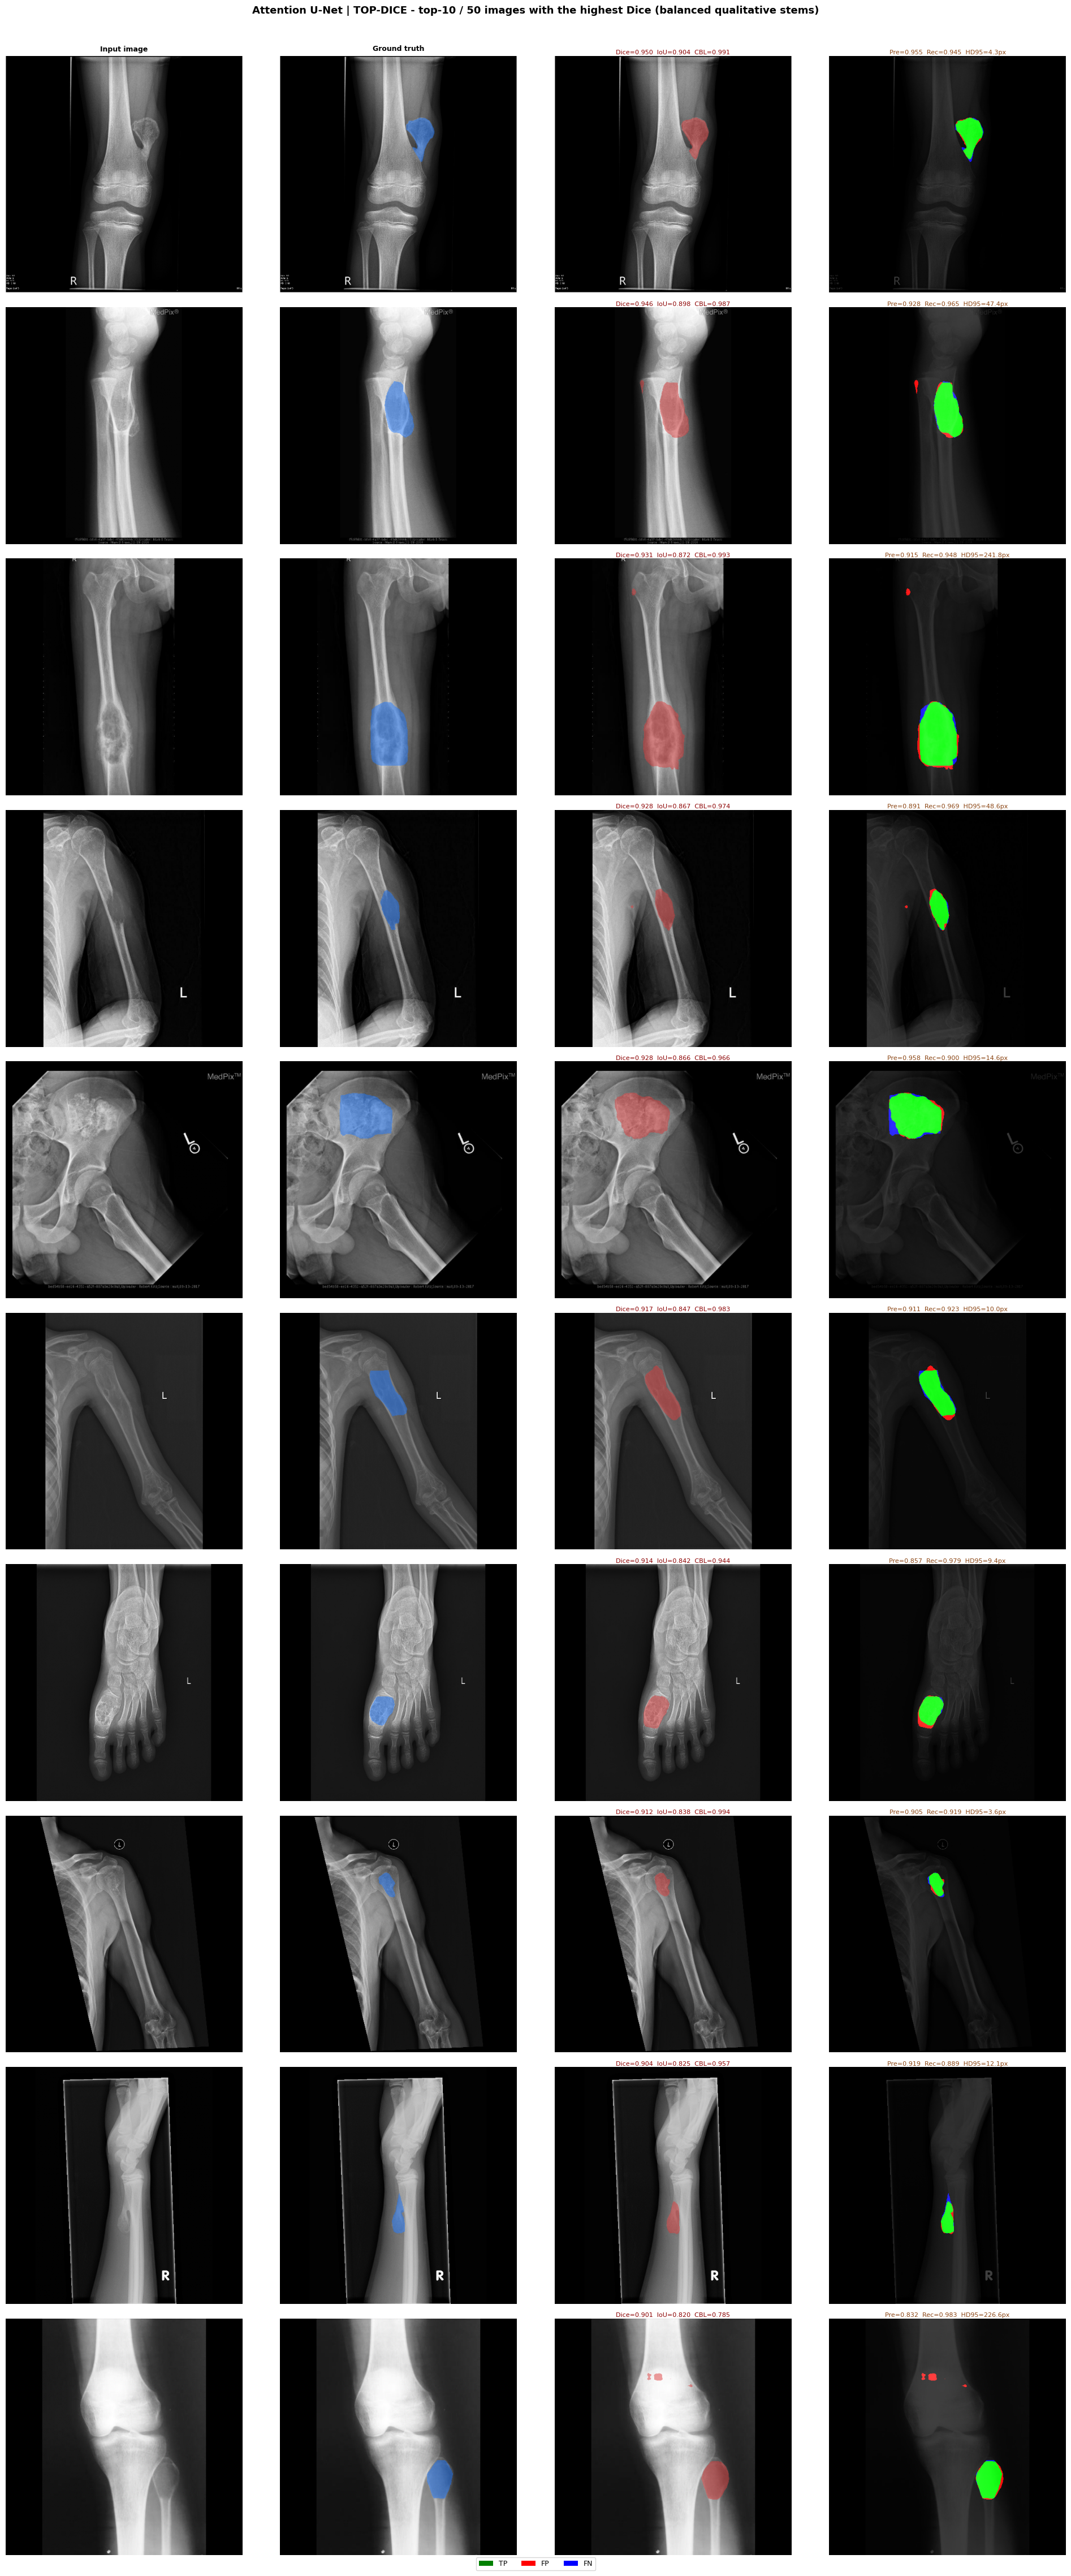

  ✅ attent_top-.png


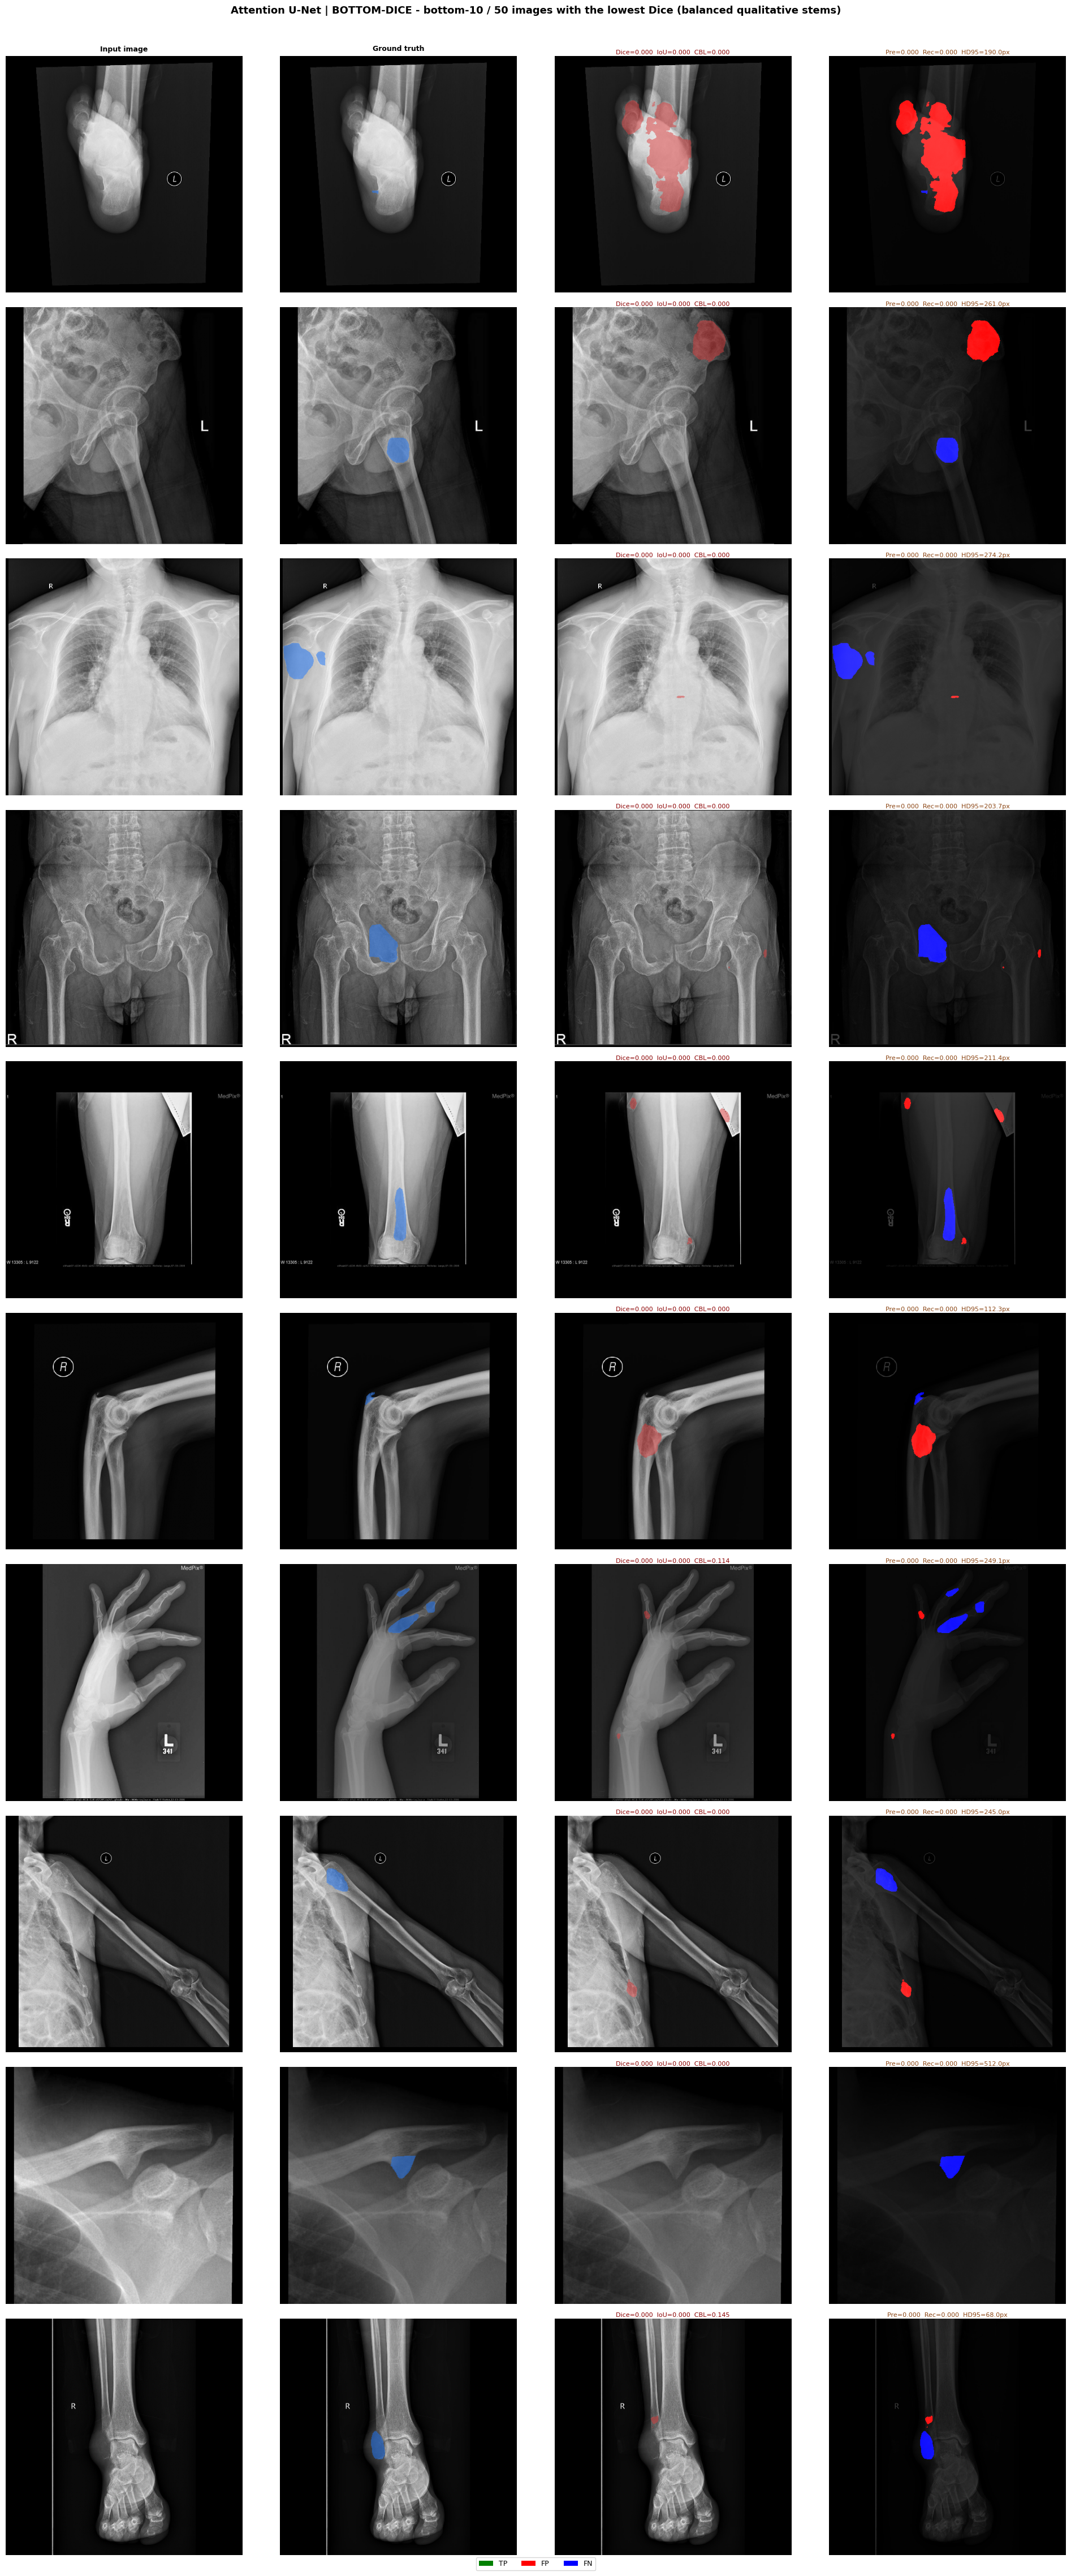

  ✅ attent_bott.png


In [3]:
# ══════════════════════════════════════════════════════
# SECTION 0+1 - Attention U-Net
# Run on the full test set -> sort by Dice -> define TOP-DICE / BOTTOM-DICE stems
# (post hoc grouping by the Attention U-Net Dice scores, not by pre-assigned image difficulty)
# Metrics: N_METRIC=50 | Visualize: N_SHOW=10
# ══════════════════════════════════════════════════════
N_METRIC = 50   # number of images used for metric computation
N_SHOW = 10     # number of images displayed

%cd /content/PGA_Unet2D
for _k in list(sys.modules.keys()):
    if 'models' in _k: del sys.modules[_k]
if '/content/PGA_Unet2D' not in sys.path:
    sys.path.insert(0, '/content/PGA_Unet2D')
else:
    sys.path.remove('/content/PGA_Unet2D'); sys.path.insert(0, '/content/PGA_Unet2D')

from models.networks.attention_unet_2D import Attention_UNet_2D
att_unet=Attention_UNet_2D(in_channels=1,n_classes=1).to(DEVICE)
att_unet.load_state_dict(torch.load('/content/checkpoints/att_unet_best.pth',map_location=DEVICE,weights_only=True))
att_unet.eval(); print('✅ Attention U-Net loaded')

all_att_unet_res=[]
with torch.no_grad():
    for s in tqdm(all_raw,'AttUNet-All'):
        prob=torch.sigmoid(att_unet(s['img_t'].to(DEVICE)))[0,0].cpu().numpy()
        all_att_unet_res.append(calc_metrics(prob,s['gt']))
del att_unet

sorted_all=sorted(range(len(all_raw)),key=lambda i:all_att_unet_res[i]['dice'],reverse=True)
easy_idx=sorted_all[:N_METRIC]
hard_idx=sorted_all[-N_METRIC:][::-1]

easy_stems=[all_raw[i]['stem'] for i in easy_idx]   # TOP-DICE: images with the best Attention U-Net predictions
hard_stems =[all_raw[i]['stem'] for i in hard_idx]  # BOTTOM-DICE: images with the worst Attention U-Net predictions

def select_balanced_test_stems_from_all(stems, all_samples, n_multi=5, n_single=5):
    counts = {}
    for item in all_samples:
        counts[item['stem']] = counts.get(item['stem'], 0) + 1
    multi = [st for st in stems if counts.get(st, 0) >= 2]
    single = [st for st in stems if counts.get(st, 0) == 1]
    chosen = multi[:n_multi] + single[:n_single]
    if len(chosen) < (n_multi + n_single):
        chosen += [st for st in stems if st not in chosen][:(n_multi + n_single - len(chosen))]
    return chosen

top_dice_balanced_test_stems = select_balanced_test_stems_from_all(easy_stems, all_raw, 5, 5)
bottom_dice_balanced_test_stems = select_balanced_test_stems_from_all(hard_stems, all_raw, 5, 5)

print(f'\n  TOP-DICE top-{N_METRIC} (best Attention U-Net predictions)    Dice: {all_att_unet_res[easy_idx[0]]["dice"]:.4f} → {all_att_unet_res[easy_idx[-1]]["dice"]:.4f}')
print(f'  BOTTOM-DICE bottom-{N_METRIC} (worst Attention U-Net predictions)  Dice: {all_att_unet_res[hard_idx[0]]["dice"]:.4f} → {all_att_unet_res[hard_idx[-1]]["dice"]:.4f}')
print(f'\neasy_stems  (TOP-DICE)    = {easy_stems}')
print(f'hard_stems  (BOTTOM-DICE) = {hard_stems}')

bar='='*70
print(f'\n{bar}\n  SECTION 1 - Attention U-Net  (metrics N={N_METRIC}, show N={N_SHOW})\n{bar}')
SEC['att_unet']={
    'easy': print_metrics(f'TOP-DICE (N={N_METRIC})', [all_att_unet_res[i] for i in easy_idx]),
    'hard': print_metrics(f'BOTTOM-DICE (N={N_METRIC})', [all_att_unet_res[i] for i in hard_idx])
}

stem2idx={all_raw[i]['stem']:i for i in range(len(all_raw))}
recs_e=[dict(**all_raw[stem2idx[st]], m=all_att_unet_res[stem2idx[st]]) for st in top_dice_balanced_test_stems]
recs_h=[dict(**all_raw[stem2idx[st]], m=all_att_unet_res[stem2idx[st]]) for st in bottom_dice_balanced_test_stems]
visualize(recs_e, f'Attention U-Net | TOP-DICE - top-{N_SHOW} / {N_METRIC} images with the highest Dice (balanced qualitative stems)', n=N_SHOW)
visualize(recs_h, f'Attention U-Net | BOTTOM-DICE - bottom-{N_SHOW} / {N_METRIC} images with the lowest Dice (balanced qualitative stems)', n=N_SHOW)

/content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation
✅ PGA-UNet loaded
  Running PGA inference per-image ...

  SECTION 3 - PGA-UNet (image-level, N=50 stems, using the same TOP-DICE/BOTTOM-DICE groups defined from Attention U-Net)
  TOP-DICE (50 images) Dice=0.9036 IoU=0.8266 Pre=0.8749 Rec=0.9385 HD95=9.23 CBL=0.9709
  BOTTOM-DICE (50 images) Dice=0.8521 IoU=0.7527 Pre=0.8392 Rec=0.8755 HD95=5.19 CBL=0.9459


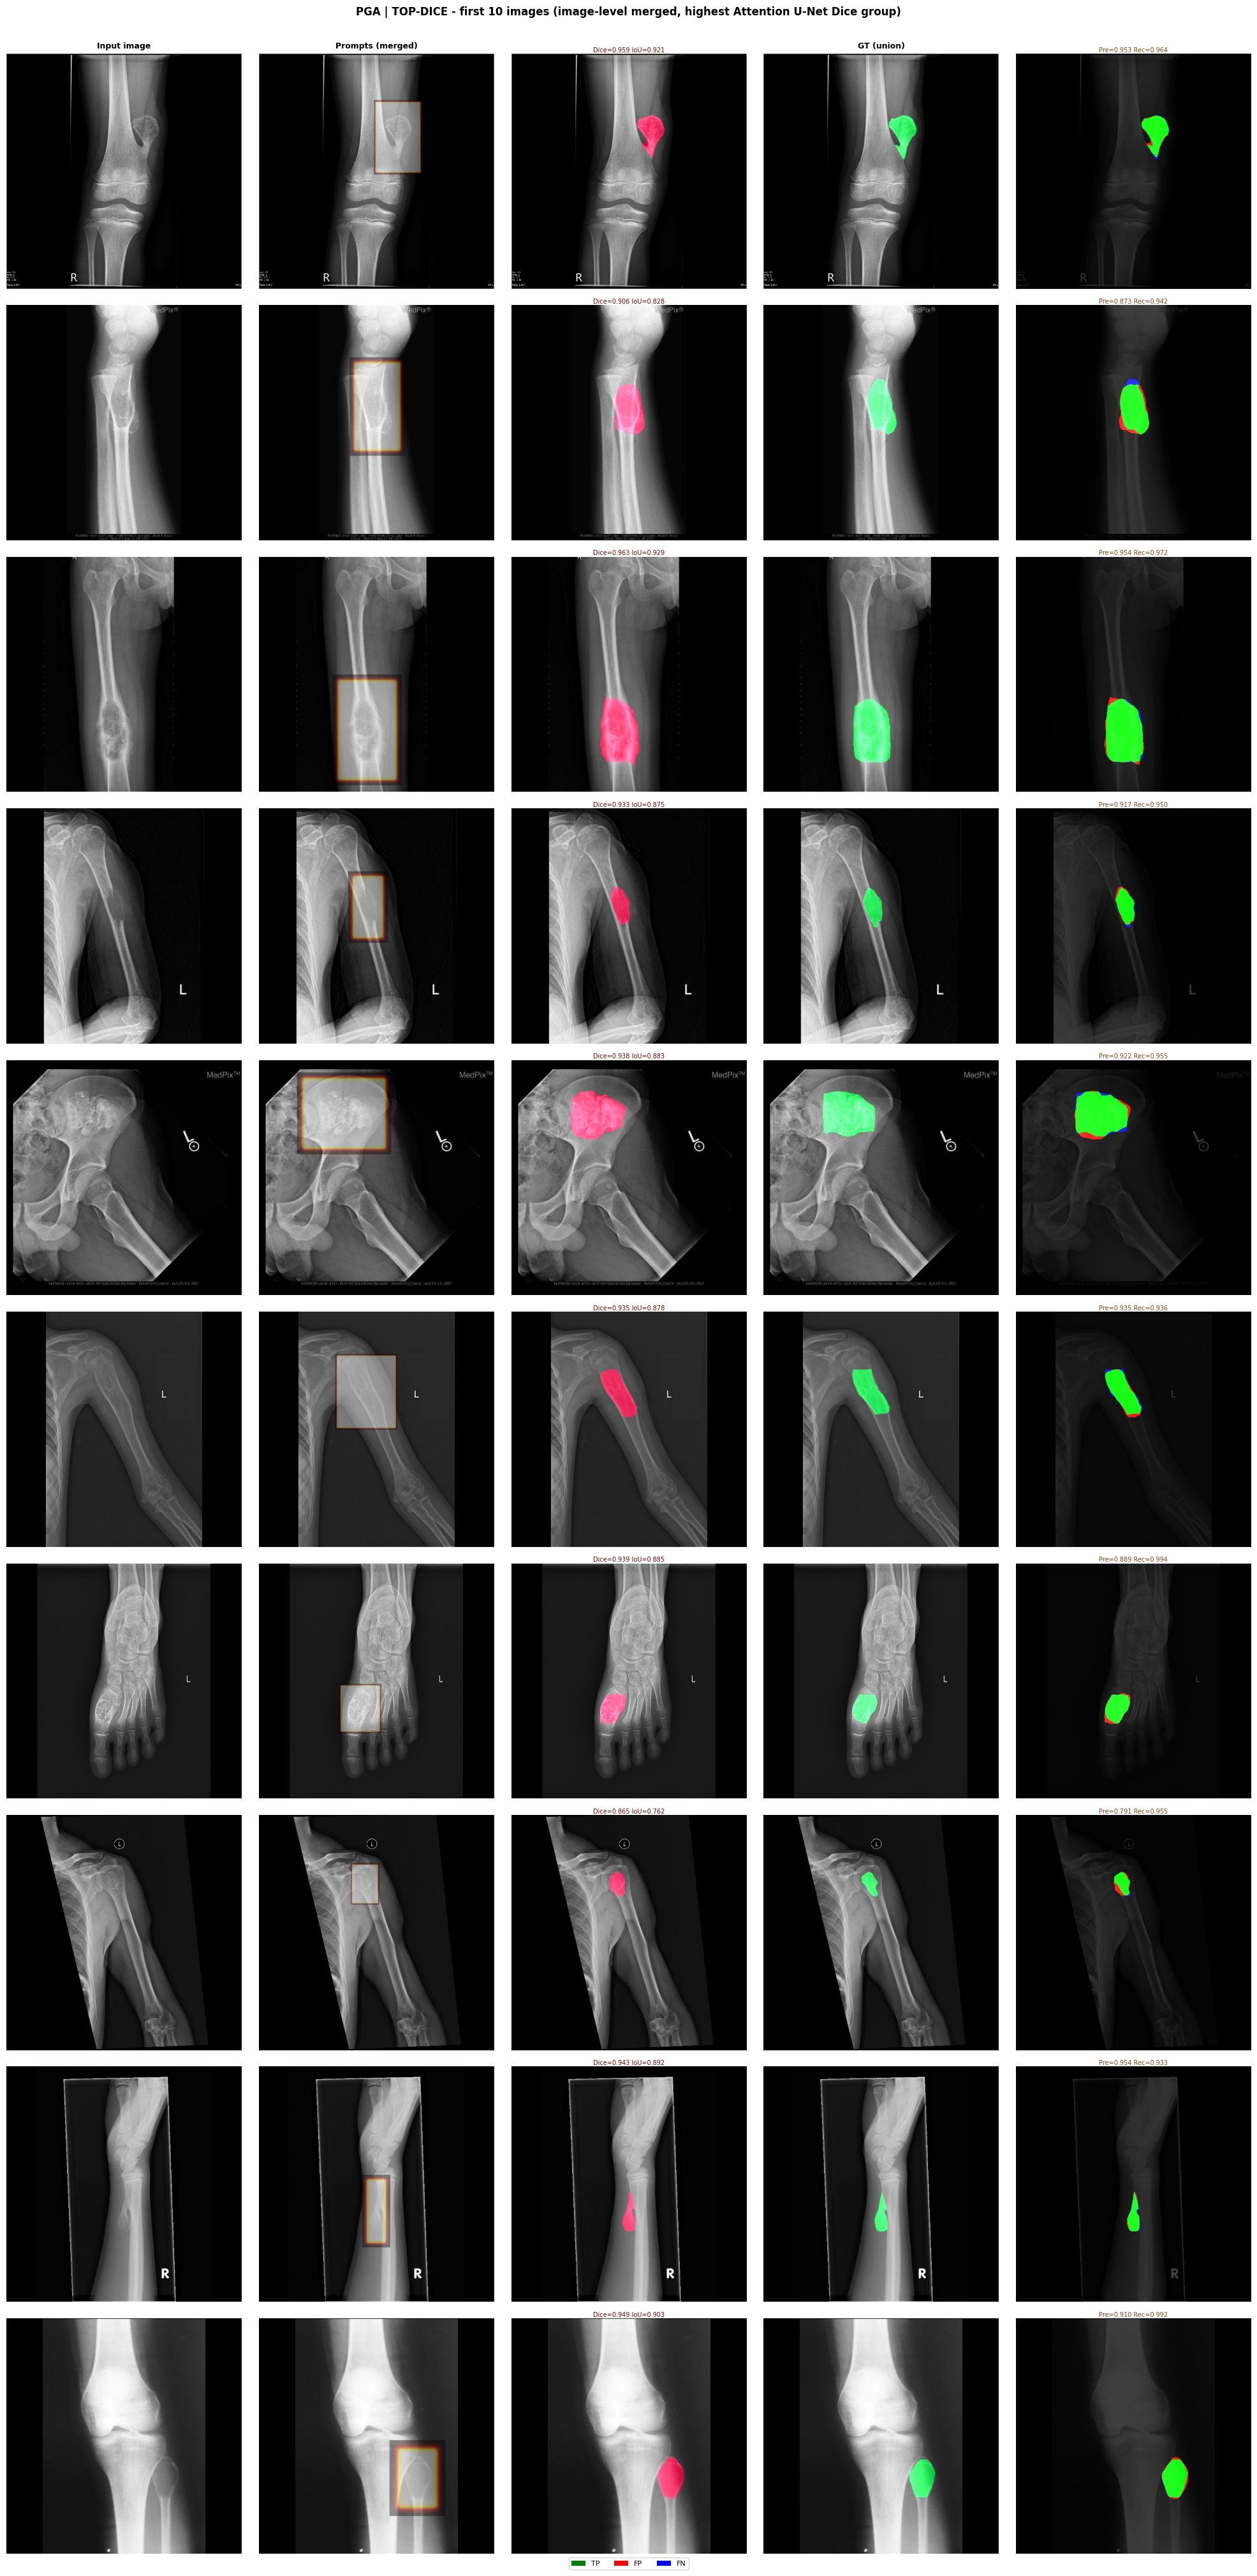

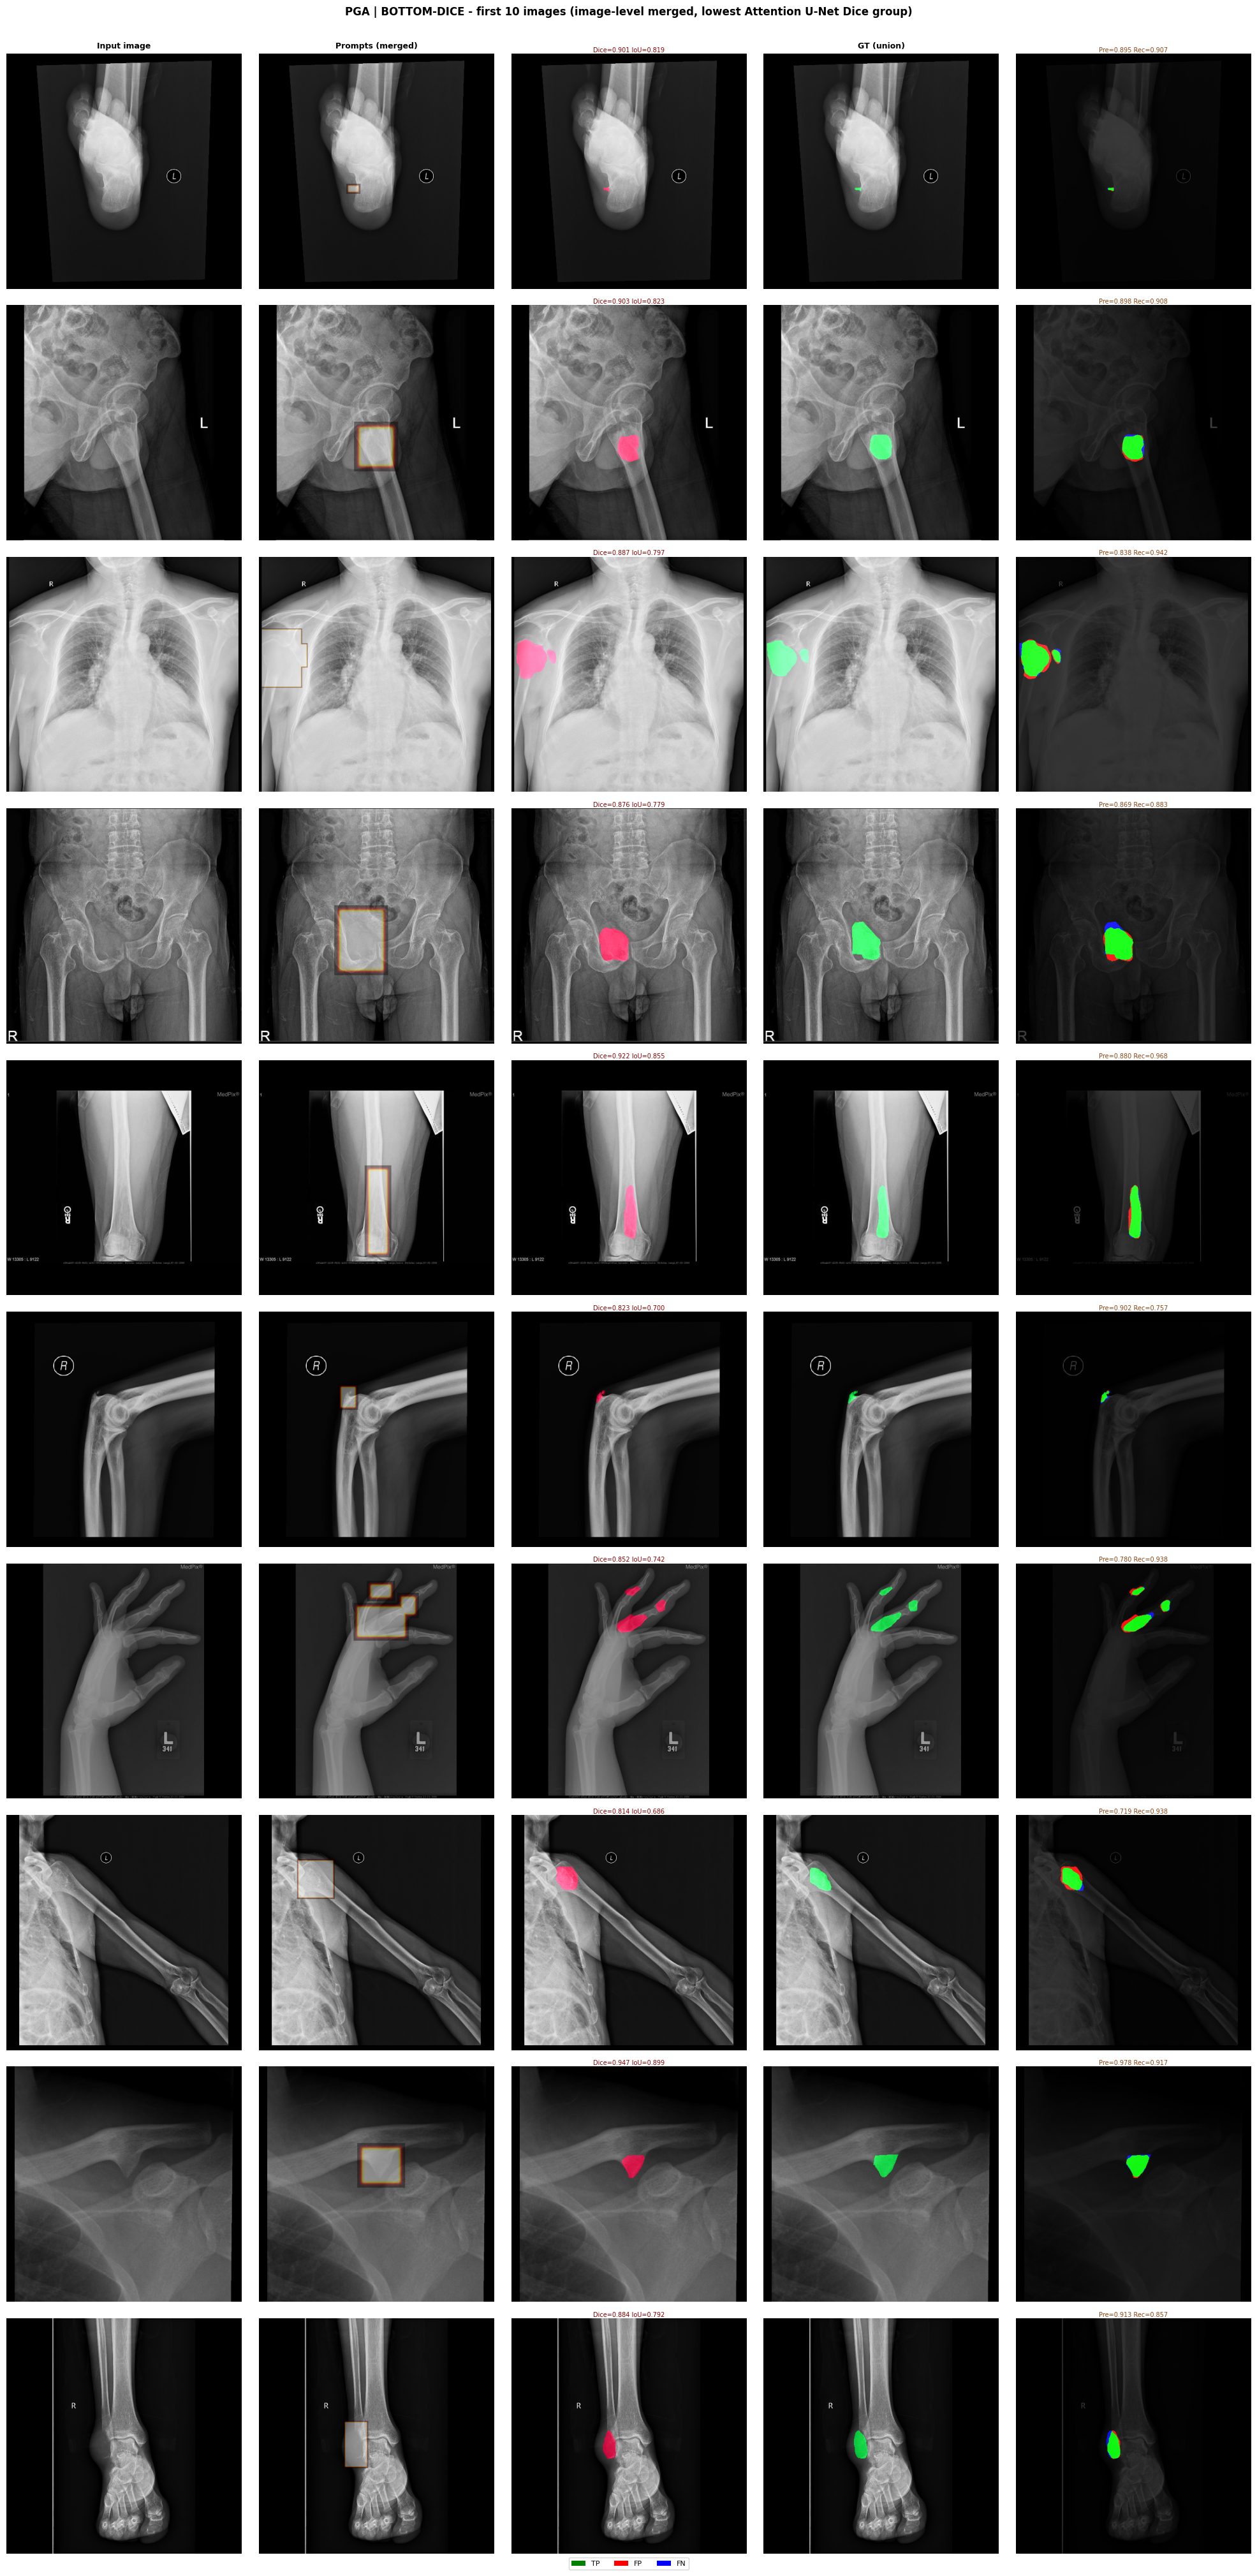

In [4]:
# ══════════════════════════════════════════════════════
# SECTION 3 - PGA-UNet  (IMAGE-LEVEL merging)
# For each image: run all polygons, max-merge the probabilities, union the GT masks, then compute image-level metrics
# ══════════════════════════════════════════════════════

_EASY = []   # paste `easy_stems` from cell 2 when running this notebook independently
_HARD  = []
_N_METRIC, _N_SHOW = 50, 10
if 'easy_stems' not in dir() or not easy_stems: easy_stems, hard_stems = _EASY, _HARD
if 'N_METRIC'   not in dir(): N_METRIC = _N_METRIC
if 'N_SHOW'     not in dir(): N_SHOW   = _N_SHOW
assert easy_stems and hard_stems, "❌ Paste `easy_stems` / `hard_stems` from cell 2 into `_EASY` / `_HARD`."

%cd /content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation
for _k in list(sys.modules.keys()):
    if 'models' in _k: del sys.modules[_k]
if '/content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation' not in sys.path:
    sys.path.insert(0, '/content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation')
else:
    sys.path.remove('/content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation'); sys.path.insert(0, '/content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation')

from models.networks.prompt_unet_2D import PGA_UNet
import importlib.util, torch
_spec=importlib.util.spec_from_file_location('pga_ds_mod','/content/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset.py')
_mod=importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_mod)
PGA_Dataset=_mod.PromptSegmentationDataset

pga=PGA_UNet(in_channels=1,n_classes=1,use_encoder_prompt=True).to(DEVICE)
pga.load_state_dict(torch.load('/content/checkpoints/pga_unet_zoom_out_512_best.pth',
                                map_location=DEVICE,weights_only=True))
pga.eval(); print('✅ PGA-UNet loaded')

pga_ds=PGA_Dataset(image_dir=IMG_DIR, json_dir=JSON_DIR,
                   img_size=IMG_SIZE, is_train=False, prompt_mode='zoom_out')

stem_to_pga={}
for i,(img_name,_) in enumerate(pga_ds.all_samples):
    stem_to_pga.setdefault(os.path.splitext(img_name)[0],[]).append(i)


def calc_metrics_img(prob, gt, eps=1e-6, IMG_S=512):
    """Image-level evaluation: no LCC filtering (multiple polygons). Uses GT union and max-merged probabilities."""
    pm = (prob > 0.5).astype(np.float32)
    gm = (gt   > 0.5).astype(np.float32)
    tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum()
    p, g = pm.astype(bool), gm.astype(bool); hd95 = float(IMG_S)
    if p.any() and g.any():
        from scipy.ndimage import binary_erosion, distance_transform_edt
        pe=p^binary_erosion(p); ge=g^binary_erosion(g)
        d1=distance_transform_edt(~ge)[pe]; d2=distance_transform_edt(~pe)[ge]
        if len(d1) and len(d2): hd95=float(max(np.percentile(d1,95),np.percentile(d2,95)))
    if gm.sum()==0 or pm.sum()==0: cbl=0.
    else:
        ys,xs=np.where(gm>0.5); yp,xp=np.where(pm>0.5)
        d=np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+eps
        cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/d,0,1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)), iou=float((tp+eps)/(tp+fp+fn+eps)),
                precision=(float(tp/(tp+fp)) if (tp+fp)>0 else 0.),   recall=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95, cbl=cbl, mask=pm)


def infer_pga_image(stem):
    """Run PGA on all polygons for a stem and return `img_np`, `gt_union`, `prob_max`, and `prompts`."""
    idxs = stem_to_pga.get(stem, [])
    if not idxs: return None
    gt_union = None; prob_max = None; prompts = []; img_np = None
    with torch.no_grad():
        for idx in idxs:
            img_t, gt_t, hm_t = pga_ds[idx]
            if img_np is None: img_np = img_t[0].numpy()
            gt_np = gt_t[0].numpy(); hm_np = hm_t[0].numpy()
            prob  = torch.sigmoid(pga(img_t.unsqueeze(0).to(DEVICE),
                                      hm_t.unsqueeze(0).to(DEVICE)))[0,0].cpu().numpy()
            gt_union = gt_np if gt_union is None else np.maximum(gt_union, gt_np)
            prob_max = prob  if prob_max is None else np.maximum(prob_max, prob)
            prompts.append(hm_np)
    return dict(stem=stem, img_np=img_np, gt=gt_union, prob=prob_max,
                prompts=prompts, n_samples=len(idxs))

print('  Running PGA inference per-image ...')
easy_img = [r for r in (infer_pga_image(s) for s in easy_stems) if r]
hard_img  = [r for r in (infer_pga_image(s) for s in hard_stems)  if r]
del pga

for r in easy_img + hard_img:
    r['m'] = calc_metrics_img(r['prob'], r['gt'])

bar='='*70
print(f'\n{bar}\n  SECTION 3 - PGA-UNet (image-level, N={N_METRIC} stems, using the same TOP-DICE/BOTTOM-DICE groups defined from Attention U-Net)\n{bar}')
SEC['pga'] = {
    'easy': print_metrics(f"TOP-DICE ({len(easy_img)} images)", [r['m'] for r in easy_img]),
    'hard': print_metrics(f"BOTTOM-DICE ({len(hard_img)} images)",  [r['m'] for r in hard_img]),
    'n_easy': len(easy_img), 'n_hard': len(hard_img),
}

def visualize_img(records, title, n=10):
    """Image-level vis: merged pred + GT union."""
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from IPython.display import display as _disp
    recs = records[:n]; nr = len(recs)
    if nr == 0: return
    fig, axes = plt.subplots(nr, 5, figsize=(20, 4*nr), squeeze=False)
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.002)
    for j,t in enumerate(['Input image','Prompts (merged)','Prediction (merged)','GT (union)','TP/FP/FN']):
        axes[0,j].set_title(t, fontsize=9, fontweight='bold')
    for row, rec in enumerate(recs):
        img_np = np.clip((rec['img_np']*0.5+0.5), 0, 1)
        gt     = (rec['gt']>0.5).astype(float)
        pred   = (rec['prob']>0.5).astype(float)
        pm_merged = np.max(np.stack(rec['prompts'],0),0) if rec.get('prompts') else np.zeros_like(img_np)
        tp=(pred*gt).sum(); fp=(pred*(1-gt)).sum(); fn=((1-pred)*gt).sum(); e=1e-6
        dice=float((2*tp+e)/(2*tp+fp+fn+e)); iou=float((tp+e)/(tp+fp+fn+e))
        pre=float((tp+e)/(tp+fp+e));         rec_=float((tp+e)/(tp+fn+e))
        n_poly = rec.get('n_samples', '?')
        bg = np.stack([img_np]*3,-1)
        axes[row,0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        axes[row,0].set_ylabel(f"{rec['stem']} [{n_poly}p]\nDice={dice:.3f}", fontsize=7)
        axes[row,1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        axes[row,1].imshow(np.where(pm_merged>0,pm_merged,np.nan), cmap='hot', alpha=0.4, vmin=0, vmax=1)
        pr_ov=bg.copy(); pr_ov[...,0]=np.clip(pr_ov[...,0]+pred*0.55,0,1); pr_ov[...,1]=np.clip(pr_ov[...,1]-pred*0.2,0,1)
        axes[row,2].imshow(pr_ov); axes[row,2].set_title(f'Dice={dice:.3f} IoU={iou:.3f}',fontsize=7,color='darkred',pad=2)
        gt_ov=bg.copy(); gt_ov[...,1]=np.clip(gt_ov[...,1]+gt*0.55,0,1); gt_ov[...,0]=np.clip(gt_ov[...,0]-gt*0.2,0,1)
        axes[row,3].imshow(gt_ov)
        inter=bg.copy()*0.25
        inter[...,1]=np.clip(inter[...,1]+pred*gt*0.9,0,1)
        inter[...,0]=np.clip(inter[...,0]+pred*(1-gt)*1.0,0,1)
        inter[...,2]=np.clip(inter[...,2]+(1-pred)*gt*1.0,0,1)
        axes[row,4].imshow(inter); axes[row,4].set_title(f'Pre={pre:.3f} Rec={rec_:.3f}',fontsize=7,color='saddlebrown',pad=2)
        for ax in axes[row]: ax.axis('off')
    fig.legend(handles=[Patch(facecolor='green',label='TP'),Patch(facecolor='red',label='FP'),Patch(facecolor='blue',label='FN')],
               loc='lower center',ncol=3,fontsize=8,bbox_to_anchor=(0.5,-0.004))
    plt.tight_layout(); _disp(fig); plt.close(fig)

visualize_img(easy_img[:N_SHOW], f'PGA | TOP-DICE - first {N_SHOW} images (image-level merged, highest Attention U-Net Dice group)')
visualize_img(hard_img[:N_SHOW],  f'PGA | BOTTOM-DICE - first {N_SHOW} images (image-level merged, lowest Attention U-Net Dice group)')


══════════════════════════════════════════════════════════════════════════════════════════
  SUMMARY TABLE |  50 TOP-DICE + 50 BOTTOM-DICE images (image-level)
  (post hoc grouping by Attention U-Net Dice on the full test set, not by pre-assigned image difficulty)
══════════════════════════════════════════════════════════════════════════════════════════
  Model          Subset            N    Dice     IoU     Pre     Rec     HD95     CBL
  ------------------------------------------------------------------------------
  Attention U-Net TOP-DICE        50 images  0.8629  0.7613  0.8424  0.8967    39.32  0.9436
  Attention U-Net BOTTOM-DICE     50 images  0.0335  0.0182  0.0897  0.0964   270.72  0.0928
  ------------------------------------------------------------------------------
  PGA-UNet       TOP-DICE        50 images  0.9036  0.8266  0.8749  0.9385     9.23  0.9709
  PGA-UNet       BOTTOM-DICE     50 images  0.8521  0.7527  0.8392  0.8755     5.19  0.9459
  -----------------------

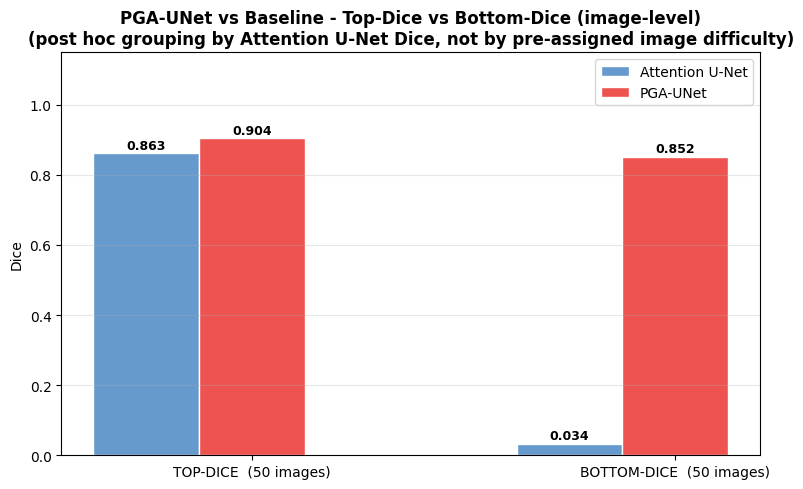

Saved plot: results/subcat_attention_unet_bar.png


In [5]:
# ══════════════════════════════════════════════════════
# SUMMARY CELL - Comparison of two models on the same 50+50 images
# All models are evaluated at the IMAGE LEVEL (Attention U-Net on the whole image, PGA with per-polygon max-merged predictions).
# The TOP-DICE/BOTTOM-DICE subsets are defined post hoc from Attention U-Net Dice scores rather than from pre-assigned image difficulty.
# ══════════════════════════════════════════════════════
import csv, os

GRP_LABEL = {'easy': 'TOP-DICE', 'hard': 'BOTTOM-DICE'}

N_EASY = len(easy_stems)   # = 50
N_HARD = len(hard_stems)   # = 50

bar = '═'*90
print(f'\n{bar}')
print(f'  SUMMARY TABLE |  {N_EASY} {GRP_LABEL["easy"]} + {N_HARD} {GRP_LABEL["hard"]} images (image-level)')
print(f'  (post hoc grouping by Attention U-Net Dice on the full test set, not by pre-assigned image difficulty)')
print(f'{bar}')
print(f"  {'Model':<14} {'Subset':<12} {'N':>6} {'Dice':>7} {'IoU':>7} {'Pre':>7} {'Rec':>7} {'HD95':>8} {'CBL':>7}")
print(f"  {'-'*78}")

csv_rows = []
for model, key in [('Attention U-Net', 'att_unet'),
 ('PGA-UNet', 'pga')]:
    for grp in ['easy', 'hard']:
        m = SEC[key][grp]
        n = N_EASY if grp == 'easy' else N_HARD
        print(f"  {model:<14} {GRP_LABEL[grp]:<12} {n:>5} images"
              f" {m['dice']:>7.4f} {m['iou']:>7.4f} {m['precision']:>7.4f}"
              f" {m['recall']:>7.4f} {m['hd95']:>8.2f} {m['cbl']:>7.4f}")
        csv_rows.append([model, GRP_LABEL[grp], n] + [f"{m[k]:.4f}" for k in KEYS])
    print(f"  {'-'*78}")

print(f"  {'Delta PGA-UNet':<14} {GRP_LABEL['easy']:<12} {'':<6}"
      f" {SEC['pga']['easy']['dice']-SEC['att_unet']['easy']['dice']:>+7.4f}")
print(f"  {'':14} {GRP_LABEL['hard']:<12} {'':<6}"
      f" {SEC['pga']['hard']['dice']-SEC['att_unet']['hard']['dice']:>+7.4f}")
print(bar)

os.makedirs('results', exist_ok=True)
with open('results/subcat_pga_vs_attention_unet.csv', 'w', newline='') as f:
    csv.writer(f).writerows([['model', 'group', 'N'] + KEYS] + csv_rows)
print('Saved CSV: results/subcat_pga_vs_attention_unet.csv')

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2); w = 0.25
for i, (label, key, clr) in enumerate([('Attention U-Net', 'att_unet', '#6699cc'),
                                         ('PGA-UNet', 'pga', '#ef5350')]):
    vals = [SEC[key]['easy']['dice'], SEC[key]['hard']['dice']]
    bars = ax.bar(x + (i-1)*w, vals, w, label=label, color=clr, edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.012, f'{v:.3f}',
                ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{GRP_LABEL["easy"]}  ({N_EASY} images)', f'{GRP_LABEL["hard"]}  ({N_HARD} images)'], fontsize=10)
ax.set_ylabel('Dice'); ax.set_ylim(0, 1.15)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.set_title('PGA-UNet vs Baseline - Top-Dice vs Bottom-Dice (image-level)\n'
             '(post hoc grouping by Attention U-Net Dice, not by pre-assigned image difficulty)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/subcat_attention_unet_bar.png', dpi=130, bbox_inches='tight'); plt.show()
print('Saved plot: results/subcat_attention_unet_bar.png')